# Evaluate the deployed model — no retraining

Pulls the trained model from the HuggingFace Hub (`suhanii23/retinopathy-model`)
and evaluates it on the APTOS 2019 validation split.

**Why this is valid without retraining:** the split is fully deterministic —
`test_size=0.15`, `random_state=2006`, `stratify=y`. This notebook reconstructs
the identical 550-image validation set the model was originally selected on, so
the metrics it produces are the true metrics for this model.

### Before you run
1. **Add Data** -> search `aptos2019-blindness-detection` -> Add
2. **Settings -> Accelerator -> GPU P100** (optional; ~3x faster)
3. **Run All** (about 10-15 minutes, nearly all of it preprocessing)

### When it finishes
Send back `metrics.json` and the classification report.

In [8]:
!pip install -q huggingface_hub

import os, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm.auto import tqdm

%matplotlib inline
print("TensorFlow:", tf.__version__)

DATA_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
IMAGE_SIZE   = 299
BATCH_SIZE   = 16
VAL_FRACTION = 0.15
SEED         = 2006          # must match the original training run
CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

TensorFlow: 2.20.0


## 1. Download the model from the Hub

This is the exact file your live Space loads, so whatever we measure here is
what your deployed app is actually doing.

In [9]:
import os, shutil, numpy as np
from huggingface_hub import hf_hub_download
from tensorflow.keras.models import load_model

REPO_ID = "suhanii23/retinopathy-model"

path = hf_hub_download(repo_id=REPO_ID, filename="diabetic_retinopathy_model.keras")
print(f"Size: {os.path.getsize(path)/1024/1024:.1f} MB")

# The file is named .keras but is actually legacy HDF5. Keras 3 validates that a
# .keras file is a zip archive and refuses to open it. Copying to a .h5 extension
# routes it through the legacy HDF5 loader instead.
h5_path = "/kaggle/working/_model_legacy.h5"
shutil.copy(path, h5_path)

try:
    model = load_model(h5_path, compile=False)
    print("Loaded via Keras 3 legacy h5")
except Exception as e:
    print(f"Keras 3 failed: {type(e).__name__}: {str(e)[:200]}")
    os.system("pip install -q tf-keras")
    import tf_keras
    model = tf_keras.models.load_model(h5_path, compile=False)
    print("Loaded via tf_keras")

MODEL_PATH = h5_path
print("\nOutput shape:", model.output_shape)
assert model.output_shape[-1] == 5

probe = model.predict(np.zeros((1, 299, 299, 3), dtype=np.float32), verbose=0)
print(f"Probe sums to {probe.sum():.4f} -> {'softmax confirmed' if abs(probe.sum()-1) < 0.01 else 'NOT softmax'}")

Size: 287.1 MB
Keras 3 failed: TypeError: Error when deserializing class 'Conv2D' using config={'name': 'block1_conv1', 'trainable': True, 'dtype': 'float32', 'filters': 32, 'kernel_size': [3, 3], 'strides': [2, 2], 'padding': 'valid', 'data_
Loaded via tf_keras

Output shape: (None, 5)
Probe sums to 1.0000 -> softmax confirmed


## 2. Preprocessing

Identical to training: crop black border -> resize 299 -> Ben Graham high-pass
(`4*I - 4*blur(I) + 128`) -> scale to **[-1, 1]** via Xception's `preprocess_input`.

The [-1, 1] range matters. Xception was pretrained on inputs in that range;
using [0, 1] shifts every input off the distribution its filters expect. (Your
deployed `app.py` was doing exactly that — see the action plan.)

In [10]:
from tensorflow.keras.applications.xception import preprocess_input

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
        return img
    return np.stack([img[:, :, i][np.ix_(mask.any(1), mask.any(0))] for i in range(3)], axis=-1)

def preprocess_image(path, sigma_x=10):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigma_x), -4, 128)
    return preprocess_input(image.astype(np.float32))

def for_display(img):
    return np.clip((img + 1) / 2, 0, 1)

## 3. Rebuild the exact validation split

In [11]:
from sklearn.model_selection import train_test_split

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
train_df['diagnosis'] = train_df['diagnosis'].astype(int)
print(f"Total images: {len(train_df)}")

X = np.empty((len(train_df), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
for i, image_id in enumerate(tqdm(train_df['id_code'], desc='Preprocessing')):
    X[i] = preprocess_image(f'{DATA_DIR}/train_images/{image_id}.png')

y = train_df['diagnosis'].values

_, x_val, _, y_val = train_test_split(
    X, y, test_size=VAL_FRACTION, random_state=SEED, stratify=y)

del X   # free ~3.9 GB

print(f"\nValidation set: {len(x_val)} images")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:18s} {int((y_val == i).sum()):4d}")

Total images: 3662


Preprocessing:   0%|          | 0/3662 [00:00<?, ?it/s]


Validation set: 550 images
  No DR               271
  Mild                 56
  Moderate            150
  Severe               29
  Proliferative DR     44


In [12]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.count('/') - 2
    if depth > 2: continue
    print('  ' * depth + os.path.basename(root) + '/')
    for f in files[:5]:
        print('  ' * (depth+1) + f)
    if len(files) > 5:
        print('  ' * (depth+1) + f'... +{len(files)-5} more')

input/
  competitions/
    aptos2019-blindness-detection/
      sample_submission.csv
      train.csv
      test.csv


## 4. The numbers

**QWK is the primary metric, not accuracy.** The labels are ordinal, so confusing
No DR with Proliferative is far worse than confusing Mild with Moderate — QWK
weights errors by `(i-j)^2`. And with 49% of images being No DR, a model that
predicts No DR for everything gets ~49% accuracy; kappa is chance-corrected so
that baseline scores ~0.

In [13]:
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)

probs  = model.predict(x_val, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(probs, axis=1)      # softmax head -> argmax

acc = accuracy_score(y_val, y_pred)
qwk = cohen_kappa_score(y_val, y_pred, weights='quadratic')

print("\n" + "=" * 62)
print(f"  VALIDATION ACCURACY        : {acc:.4f}   ({acc*100:.2f}%)")
print(f"  QUADRATIC WEIGHTED KAPPA   : {qwk:.4f}")
print(f"  Validation set size        : {len(y_val)}")
print("=" * 62)
print("\n>>> These two numbers go on the README and the resume. <<<")

35/35 [==============================] - 105s 3s/step

  VALIDATION ACCURACY        : 0.7709   (77.09%)
  QUADRATIC WEIGHTED KAPPA   : 0.8828
  Validation set size        : 550

>>> These two numbers go on the README and the resume. <<<


In [14]:
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=3))

                  precision    recall  f1-score   support

           No DR      0.981     0.978     0.980       271
            Mild      0.434     0.821     0.568        56
        Moderate      0.802     0.487     0.606       150
          Severe      0.349     0.759     0.478        29
Proliferative DR      0.900     0.409     0.562        44

        accuracy                          0.771       550
       macro avg      0.693     0.691     0.639       550
    weighted avg      0.837     0.771     0.776       550



### What the old app.py was doing

Demonstrating the deployed bug on your real validation predictions: the Space used
`int((probs > 0.5).sum())` — ordinal thresholding — against a softmax head.

In [15]:
buggy = np.minimum((probs > 0.5).sum(axis=1), 4)

print("Class distribution of predictions:\n")
print(f"{'':18s} {'correct (argmax)':>18s} {'deployed (>0.5 sum)':>22s}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:18s} {int((y_pred == i).sum()):>18d} {int((buggy == i).sum()):>22d}")

print(f"\nAccuracy with correct argmax logic : {accuracy_score(y_val, y_pred):.4f}")
print(f"Accuracy with the deployed logic   : {accuracy_score(y_val, buggy):.4f}")
print(f"\nClasses reachable by deployed app  : {sorted(set(buggy.tolist()))}")
print("(only two of five -- Moderate, Severe and Proliferative were impossible)")

Class distribution of predictions:

                     correct (argmax)    deployed (>0.5 sum)
No DR                             270                     55
Mild                              106                    495
Moderate                           91                      0
Severe                             63                      0
Proliferative DR                   20                      0

Accuracy with correct argmax logic : 0.7709
Accuracy with the deployed logic   : 0.0982

Classes reachable by deployed app  : [0, 1]
(only two of five -- Moderate, Severe and Proliferative were impossible)


## 5. Confusion matrix

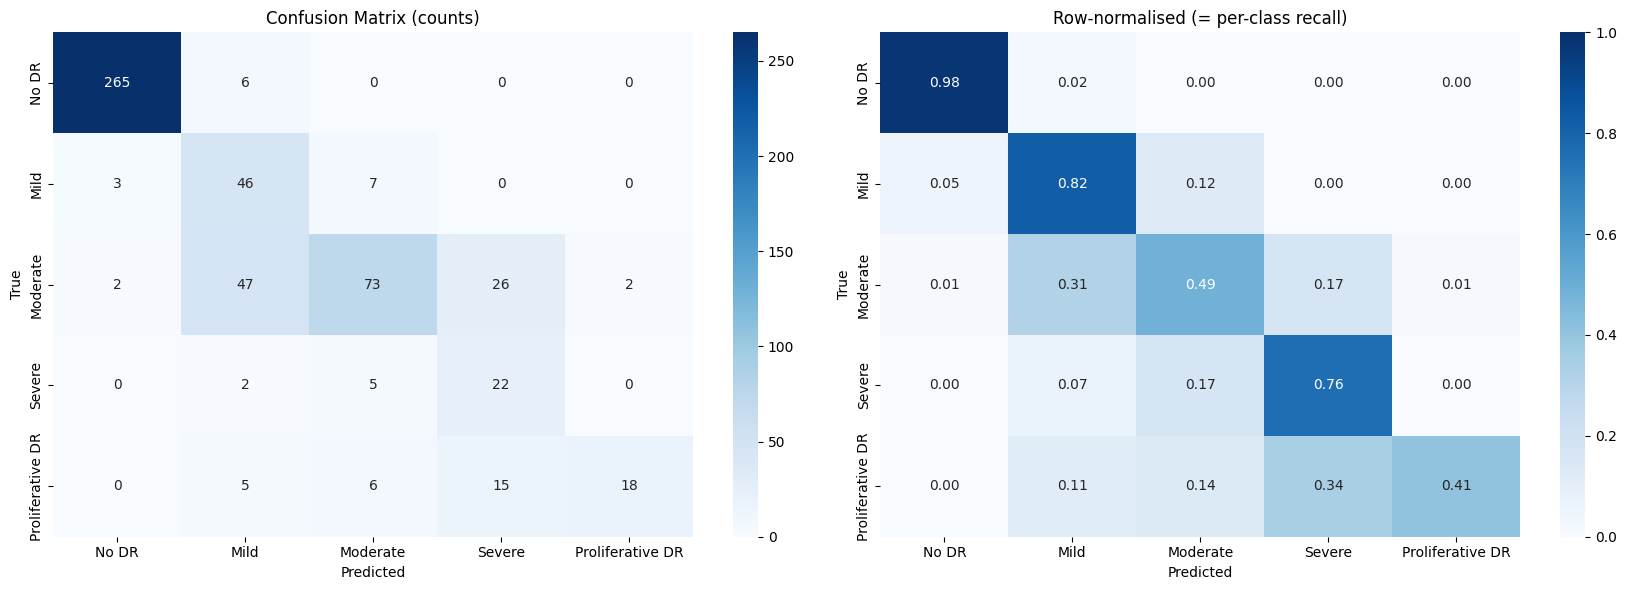

Of 126 misclassifications:
  1 class away:  109  ( 86.5%)
  2 class away:   12  (  9.5%)
  3 class away:    5  (  4.0%)
Mean error distance: 1.17 classes


In [16]:
cm = confusion_matrix(y_val, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax1.set_title('Confusion Matrix (counts)')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2, vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax2.set_title('Row-normalised (= per-class recall)')
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

# How far off are the errors? This is what QWK rewards and accuracy hides.
err = np.abs(y_val - y_pred); err = err[err > 0]
if len(err):
    print(f"Of {len(err)} misclassifications:")
    for d in range(1, 5):
        n = int((err == d).sum())
        if n:
            print(f"  {d} class away: {n:4d}  ({100*n/len(err):5.1f}%)")
    print(f"Mean error distance: {err.mean():.2f} classes")

### Referable DR

In screening the operational question is not "what exact grade?" but "does this
patient need an ophthalmologist?" — standard cutoff is Moderate or worse.
This is usually much stronger than the 5-class numbers suggest, because most
errors are between adjacent classes on the same side of the threshold.

In [17]:
yt = (y_val >= 2).astype(int)
yp = (y_pred >= 2).astype(int)

tp = int(((yt==1)&(yp==1)).sum()); tn = int(((yt==0)&(yp==0)).sum())
fp = int(((yt==0)&(yp==1)).sum()); fn = int(((yt==1)&(yp==0)).sum())

sens = tp/(tp+fn) if tp+fn else 0.0
spec = tn/(tn+fp) if tn+fp else 0.0

print("Referable DR (Moderate or worse)")
print(f"  Sensitivity : {sens:.3f}   <- missing these is the costly error")
print(f"  Specificity : {spec:.3f}")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")

with open('metrics.json', 'w') as f:
    json.dump({
        'val_accuracy': float(acc),
        'qwk': float(qwk),
        'n_val': int(len(y_val)),
        'referable_sensitivity': float(sens),
        'referable_specificity': float(spec),
        'per_class_recall': {CLASS_NAMES[i]: float((y_pred[y_val==i]==i).mean())
                             for i in range(5)},
        'confusion_matrix': cm.tolist(),
    }, f, indent=2)

print("\nSaved metrics.json  <- send me this file")
print(json.dumps(json.load(open('metrics.json')), indent=2)[:900])

Referable DR (Moderate or worse)
  Sensitivity : 0.749   <- missing these is the costly error
  Specificity : 0.979
  TP=167  TN=320  FP=7  FN=56

Saved metrics.json  <- send me this file
{
  "val_accuracy": 0.7709090909090909,
  "qwk": 0.8828471825327364,
  "n_val": 550,
  "referable_sensitivity": 0.7488789237668162,
  "referable_specificity": 0.9785932721712538,
  "per_class_recall": {
    "No DR": 0.977859778597786,
    "Mild": 0.8214285714285714,
    "Moderate": 0.4866666666666667,
    "Severe": 0.7586206896551724,
    "Proliferative DR": 0.4090909090909091
  },
  "confusion_matrix": [
    [
      265,
      6,
      0,
      0,
      0
    ],
    [
      3,
      46,
      7,
      0,
      0
    ],
    [
      2,
      47,
      73,
      26,
      2
    ],
    [
      0,
      2,
      5,
      22,
      0
    ],
    [
      0,
      5,
      6,
      15,
      18
    ]
  ]
}


## 6. Sample predictions

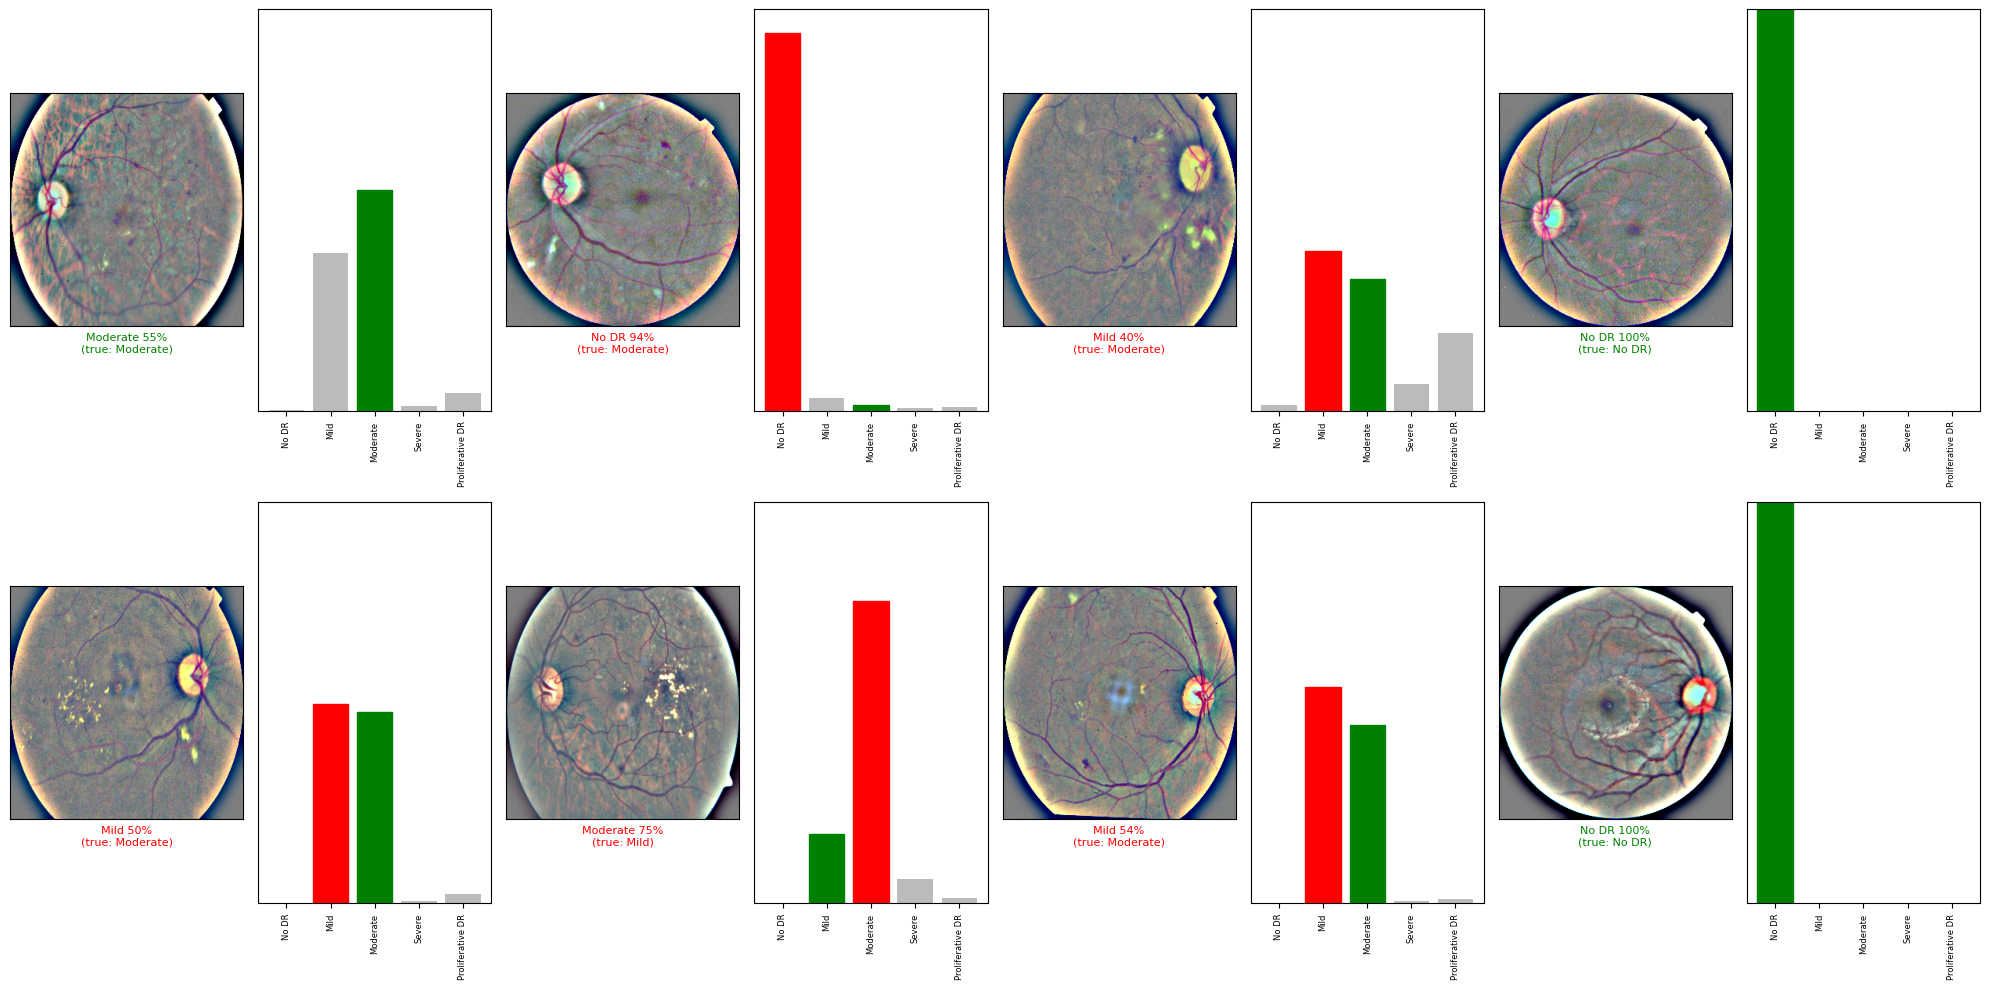

In [18]:
fig = plt.figure(figsize=(20, 10))
for i in range(8):
    ax = plt.subplot(2, 8, 2*i+1)
    ax.imshow(for_display(x_val[i])); ax.set_xticks([]); ax.set_yticks([])
    ok = y_pred[i] == y_val[i]
    ax.set_xlabel(f"{CLASS_NAMES[y_pred[i]]} {100*probs[i].max():.0f}%\n(true: {CLASS_NAMES[y_val[i]]})",
                  color='green' if ok else 'red', fontsize=8)
    ax = plt.subplot(2, 8, 2*i+2)
    bars = ax.bar(range(5), probs[i], color='#bbbbbb')
    bars[y_pred[i]].set_color('red'); bars[y_val[i]].set_color('green')
    ax.set_ylim([0,1]); ax.set_yticks([])
    ax.set_xticks(range(5)); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('validation_predictions.png', dpi=120)
plt.show()

---
## Done

`/kaggle/working/` now contains `metrics.json`, `confusion_matrix.png`,
`validation_predictions.png`.

**Send back `metrics.json` and the classification report output.**

Then: **Save Version -> Save & Run All (Commit)**, and download from the completed
version in the Versions list so the outputs are preserved.